# Prediction-Powered Inference for Clinical Trials

### Missing data + transfer learning, and what it buys a randomised trial

This notebook is the companion code for the post *"Your control arm is a missing-data
problem. Machine learning can shrink it."*

It implements and stress-tests the estimators of

> Poulet, Tran, Tezenas du Montcel, Dubois, Durrleman & Jedynak (2025).
> **Prediction-powered inference for clinical trials: application to linear covariate
> adjustment.** *BMC Medical Research Methodology* 25:204.
> [doi:10.1186/s12874-025-02647-6](https://doi.org/10.1186/s12874-025-02647-6)

which builds on

> Angelopoulos, Bates, Fannjiang, Jordan & Zrnic (2023). **Prediction-powered inference.**
> *Science* 382(6671):669-674. [doi:10.1126/science.adi6000](https://doi.org/10.1126/science.adi6000)
>
> Angelopoulos, Duchi & Zrnic (2023). **PPI++: Efficient prediction-powered inference.**
> [arXiv:2311.01453](https://arxiv.org/abs/2311.01453)

**What runs here**

| Part | Question |
|---|---|
| 1 | The classical estimator, and where its variance comes from |
| 2 | One simulated trial, five estimators, side by side |
| 3 | Are they unbiased? How much variance does prediction remove? |
| 4 | The paper's Table 2: unbalanced arms and heavy tails |
| 5 | What happens when the prognostic model is *wrong* |
| 6 | Power, and the sample size you can give back |
| 7 | **ACTG 175** — a real randomised HIV trial (2,139 patients) |
| 8 | **NHANES** — the same machinery without randomisation, and why that breaks |

Everything downloads its own data. Runtime on a free Colab CPU runtime: about 5-8 minutes.

In [1]:
#@title Setup
!pip install -q pyreadr

import numpy as np, pandas as pd, warnings
from dataclasses import dataclass
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
warnings.filterwarnings("ignore")

# --- house style (palette validated for colour-vision deficiency) -----------
C = {"Reference": "#2a78d6", "PPI": "#eb6834", "PPCT": "#1baf7a",
     "PPCT2": "#4a3aa7", "ANCOVA": "#e34948", "Naive (ML only)": "#898781"}
INK, INK2, MUTED, GRID, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
ORDER = ["Reference", "PPI", "PPCT", "PPCT2", "ANCOVA"]

plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "font.size": 11, "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2,
    "axes.titlecolor": INK, "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.titlepad": 12, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "xtick.color": MUTED,
    "ytick.color": MUTED, "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "lines.linewidth": 2, "figure.dpi": 110,
})
pd.set_option("display.width", 160)
print("ready")

ready


---
## 1. The classical estimator, and where its variance comes from

A two-arm randomised trial with $N$ participants: $m$ treated ($T_i = 1$), $n$ control
($T_i = 0$). The estimand is the average treatment effect

$$\mathrm{ATE} = \mathbb{E}[Y_i \mid T_i = 1] - \mathbb{E}[Y_i \mid T_i = 0].$$

The **reference estimator** is the difference in arm means:

$$\widehat{\mathrm{ATE}}^{\,\mathrm{ref}} = \frac{1}{m}\sum_{i:T_i=1} Y_i - \frac{1}{n}\sum_{i:T_i=0} Y_i,
\qquad
\mathbb{V}\!\left(\widehat{\mathrm{ATE}}^{\,\mathrm{ref}}\right) = \frac{\sigma_t^2}{m} + \frac{\sigma_c^2}{n}.$$

Both terms matter, and the control term is the expensive one: it is the price of learning
what would have happened without treatment. Every control patient is a patient who was
enrolled, consented, monitored, and deliberately *not* given the therapy under study.

Now suppose you have a function $f$ — trained somewhere else, on data disjoint from this
trial — that maps baseline covariates to a guess at the untreated outcome. The question
this notebook answers: **how much of the control arm can $f$ replace, and what do you have
to give up to use it?**

### The estimator library

Five estimators, all of the same estimand.

**Reference** — difference in means, above.

**PPI** (Angelopoulos et al., 2023) replaces the control mean with predictions, then
*rectifies* them using the controls you do have:

$$\widehat{\mathrm{ATE}}^{\,\mathrm{PPI}} = \frac{1}{m}\sum_{i:T_i=1}\bigl(Y_i - f(X_i)\bigr) - \frac{1}{n}\sum_{i:T_i=0}\bigl(Y_i - f(X_i)\bigr).$$

The second term is the rectifier $\hat\Delta$: the empirical bias of the model, measured on
the control arm. It is what makes the estimator unbiased *no matter how wrong $f$ is*.

**PPI++ / PPCT** (Angelopoulos et al., 2023; Poulet et al., 2025) puts a dial on it:

$$\widehat{\mathrm{ATE}}^{\,\mathrm{PPI}\lambda} = \frac{1}{m}\sum_{i:T_i=1}\bigl(Y_i - \lambda f(X_i)\bigr) - \frac{1}{n}\sum_{i:T_i=0}\bigl(Y_i - \lambda f(X_i)\bigr)
= (1-\lambda)\,\widehat{\mathrm{ATE}}^{\,\mathrm{ref}} + \lambda\,\widehat{\mathrm{ATE}}^{\,\mathrm{PPI}}.$$

Unbiased for every $\lambda$, so $\lambda$ is free to be chosen to minimise variance:

$$\lambda^* = \frac{\pi_c\,\sigma_t\rho_t + \pi_t\,\sigma_c\rho_c}{\sigma_f},
\qquad
\mathbb{V}\!\left(\widehat{\mathrm{ATE}}^{\,\mathrm{PPCT}}\right) = \frac{\sigma_t^2}{m} + \frac{\sigma_c^2}{n} - (\lambda^*)^2\sigma_f^2\left(\frac1n + \frac1m\right),$$

with $\pi_t = m/N$, $\pi_c = n/N$, and $\rho_t,\rho_c$ the within-arm correlations between
$f(X)$ and $Y$. The subtracted term is never negative: **PPCT is never worse than the
reference estimator.** At $\lambda^*=0$ (a useless model) it *is* the reference estimator.

**PPCT2** estimates $\lambda^*$ under the constant-treatment-effect assumption
$\rho_c=\rho_t$, which collapses it to $\widehat{\mathrm{Cov}}(Y,f)/\hat\sigma_f^2$ pooled
across arms — far more stable when one arm is tiny.

**ANCOVA** is the regulator-approved comparator: linear covariate adjustment on the
prognostic score, with arm-specific slopes.

In [2]:
import numpy as np
from dataclasses import dataclass
from scipy import stats


# --------------------------------------------------------------------------
# result container
# --------------------------------------------------------------------------
@dataclass
class ATEResult:
    name: str
    estimate: float
    variance: float          # variance OF THE ESTIMATOR (not the asymptotic V)
    lam: float = np.nan      # lambda actually used, where applicable

    @property
    def se(self):
        return np.sqrt(self.variance)

    def ci(self, alpha=0.05):
        z = stats.norm.ppf(1 - alpha / 2)
        return self.estimate - z * self.se, self.estimate + z * self.se

    def pvalue(self):
        if self.variance <= 0:
            return np.nan
        return 2 * (1 - stats.norm.cdf(abs(self.estimate) / self.se))

    def reject(self, alpha=0.05):
        lo, hi = self.ci(alpha)
        return not (lo <= 0 <= hi)


# --------------------------------------------------------------------------
# helpers
# --------------------------------------------------------------------------
def _split(Y, T, F):
    Y, T, F = np.asarray(Y, float), np.asarray(T, int), np.asarray(F, float)
    F = F - F.mean()                       # centre the prognostic score
    return Y[T == 1], Y[T == 0], F[T == 1], F[T == 0], F


def _moments(Yt, Yc, Ft, Fc, Fall):
    """Empirical sds and within-arm correlations (ddof=1 throughout)."""
    s_t = Yt.std(ddof=1)
    s_c = Yc.std(ddof=1)
    s_f = Fall.std(ddof=1)
    rho_t = np.corrcoef(Ft, Yt)[0, 1] if len(Yt) > 2 and Ft.std() > 0 else 0.0
    rho_c = np.corrcoef(Fc, Yc)[0, 1] if len(Yc) > 2 and Fc.std() > 0 else 0.0
    return s_t, s_c, s_f, np.nan_to_num(rho_t), np.nan_to_num(rho_c)


def lambda_star(s_t, s_c, s_f, rho_t, rho_c, m, n):
    """Variance-minimising lambda (Proposition 4).

    lambda* = (pi_c * sigma_t * rho_t + pi_t * sigma_c * rho_c) / sigma_f
    with pi_t = m/N, pi_c = n/N.
    """
    if s_f <= 0:
        return 0.0
    N = m + n
    pi_t, pi_c = m / N, n / N
    return (pi_c * s_t * rho_t + pi_t * s_c * rho_c) / s_f


# --------------------------------------------------------------------------
# estimators
# --------------------------------------------------------------------------
def reference(Y, T, F=None):
    """Difference in arm means.  Var = sigma_c^2/n + sigma_t^2/m."""
    Y, T = np.asarray(Y, float), np.asarray(T, int)
    Yt, Yc = Y[T == 1], Y[T == 0]
    m, n = len(Yt), len(Yc)
    est = Yt.mean() - Yc.mean()
    var = Yt.var(ddof=1) / m + Yc.var(ddof=1) / n
    return ATEResult("Reference", est, var, lam=0.0)


def ppi_lambda(Y, T, F, lam):
    """PPI++ estimator at a fixed lambda (Definition 4).

    ATE = mean_t(Y - lam*f) - mean_c(Y - lam*f)
    Var = (s_t^2 + lam^2 s_f^2 - 2 lam s_f s_t rho_t)/m
        + (s_c^2 + lam^2 s_f^2 - 2 lam s_f s_c rho_c)/n
    """
    Yt, Yc, Ft, Fc, Fall = _split(Y, T, F)
    m, n = len(Yt), len(Yc)
    s_t, s_c, s_f, rho_t, rho_c = _moments(Yt, Yc, Ft, Fc, Fall)
    est = (Yt - lam * Ft).mean() - (Yc - lam * Fc).mean()
    var = ((s_t**2 + lam**2 * s_f**2 - 2 * lam * s_f * s_t * rho_t) / m
           + (s_c**2 + lam**2 * s_f**2 - 2 * lam * s_f * s_c * rho_c) / n)
    return ATEResult(f"PPI(lambda={lam:.3f})", est, max(var, 0.0), lam=lam)


def ppi(Y, T, F):
    """Plain prediction-powered inference: lambda = 1 (Definition 3)."""
    r = ppi_lambda(Y, T, F, 1.0)
    return ATEResult("PPI", r.estimate, r.variance, lam=1.0)


def ppct(Y, T, F):
    """PPCT: PPI++ at the plug-in lambda* (Definition 5 / Proposition 4)."""
    Yt, Yc, Ft, Fc, Fall = _split(Y, T, F)
    m, n = len(Yt), len(Yc)
    s_t, s_c, s_f, rho_t, rho_c = _moments(Yt, Yc, Ft, Fc, Fall)
    lam = lambda_star(s_t, s_c, s_f, rho_t, rho_c, m, n)
    r = ppi_lambda(Y, T, F, lam)
    return ATEResult("PPCT", r.estimate, r.variance, lam=lam)


def ppct2(Y, T, F):
    """PPCT2: lambda* under the constant-treatment-effect assumption rho_c = rho_t.

    Then lambda* reduces to Cov(Y, f) / Var(f), estimated by pooling the
    within-arm centred products — far more stable when one arm is tiny.
    """
    Yt, Yc, Ft, Fc, Fall = _split(Y, T, F)
    m, n = len(Yt), len(Yc)
    dy = np.concatenate([Yt - Yt.mean(), Yc - Yc.mean()])
    df = np.concatenate([Ft - Ft.mean(), Fc - Fc.mean()])
    dof = m + n - 2
    s_f2 = Fall.var(ddof=1)
    lam = (dy @ df) / dof / s_f2 if (s_f2 > 0 and dof > 0) else 0.0
    r = ppi_lambda(Y, T, F, lam)
    return ATEResult("PPCT2", r.estimate, r.variance, lam=lam)


def ancova(Y, T, F):
    """Linear covariate adjustment on the prognostic score, arm-specific slopes.

    Fits Y ~ 1 + T + f~ + T:f~ with f~ centred, and reports the coefficient on T
    with a heteroskedasticity-robust (HC0 sandwich) variance.  Equivalent to
    Proposition 6's mean_t(Y - lam_t f) - mean_c(Y - lam_c f) with centred f.
    """
    Y = np.asarray(Y, float)
    T = np.asarray(T, float)
    F = np.asarray(F, float)
    Fc_ = F - F.mean()
    Z = np.column_stack([np.ones_like(Y), T, Fc_, T * Fc_])
    XtX_inv = np.linalg.pinv(Z.T @ Z)
    beta = XtX_inv @ Z.T @ Y
    resid = Y - Z @ beta
    meat = (Z * resid[:, None]).T @ (Z * resid[:, None])
    cov = XtX_inv @ meat @ XtX_inv          # HC0
    return ATEResult("ANCOVA", beta[1], cov[1, 1], lam=np.nan)


ALL_ESTIMATORS = {
    "Reference": reference,
    "PPI": ppi,
    "PPCT": ppct,
    "PPCT2": ppct2,
    "ANCOVA": ancova,
}


def run_all(Y, T, F):
    """Return {name: ATEResult} for every estimator."""
    return {k: fn(Y, T, F) for k, fn in ALL_ESTIMATORS.items()}


# --------------------------------------------------------------------------
# design quantities
# --------------------------------------------------------------------------
def sample_size(var_per_unit_N, delta, alpha=0.05, power=0.80):
    """Minimum N for a two-sided test (Proposition 8).

    N = V * ((z_{1-alpha/2} + z_{1-beta}) / delta)^2
    where V is the ASYMPTOTIC variance, i.e. Var(ATEhat) * N.
    """
    z_a = stats.norm.ppf(1 - alpha / 2)
    z_b = stats.norm.ppf(power)
    return var_per_unit_N * ((z_a + z_b) / delta) ** 2


def control_arm_ratio(rho_c):
    """n*/m = sqrt(1 - rho_c^2) — Table 1 of the paper.

    Size of the control arm, relative to a standard balanced RCT's arm size,
    needed for a PPCT-powered trial to match the balanced design's power.
    """
    rho_c = np.clip(np.asarray(rho_c, float), -1, 1)
    return np.sqrt(1 - rho_c**2)


def variance_theory(s_t, s_c, s_f, rho_t, rho_c, m, n):
    """Closed-form variances of Reference / PPI / PPCT for a given design."""
    lam = lambda_star(s_t, s_c, s_f, rho_t, rho_c, m, n)
    v_ref = s_c**2 / n + s_t**2 / m
    v_ppi = ((s_t**2 + s_f**2 - 2 * s_f * s_t * rho_t) / m
             + (s_c**2 + s_f**2 - 2 * s_f * s_c * rho_c) / n)
    v_ppct = v_ref - lam**2 * s_f**2 * (1 / n + 1 / m)
    return {"lambda_star": lam, "Reference": v_ref, "PPI": v_ppi, "PPCT": v_ppct}

---
## 2. One simulated trial

The generative model is the paper's (eqs. 13-16): a control outcome $Y_c$, a constant
treatment shift $\Delta$, and a prognostic score that is the true untreated outcome plus
noise, calibrated so that $\mathrm{corr}(f, Y) = \rho$ in both arms.

In [3]:
RNG = np.random.default_rng(20260918)

def gen_trial(m, n, rho, delta=1.0, dist="normal", rng=RNG):
    """Y_c ~ F;  Y_t = Y_c + delta;  f(X) = Y_c + eps  with corr(f, Y) = rho."""
    N = m + n
    if dist == "normal":
        Yc0, s_c = rng.normal(0, 1, N), 1.0
    else:                                       # chi-square, 5 df: skewed, heavy right tail
        Yc0, s_c = rng.chisquare(5, N), np.sqrt(10.0)
    T = np.r_[np.ones(m, int), np.zeros(n, int)]
    Y = Yc0 + delta * T
    if rho <= 0:
        F = rng.normal(0, s_c, N)               # a model that knows nothing
    else:
        F = Yc0 + rng.normal(0, s_c * np.sqrt((1 - rho**2) / rho**2), N)
    return Y, T, F


Y, T, F = gen_trial(m=100, n=100, rho=0.9, delta=1.0)
rows = []
for k, r in run_all(Y, T, F).items():
    lo, hi = r.ci()
    rows.append({"estimator": k, "ATE": r.estimate, "SE": r.se,
                 "95% CI": f"({lo:.2f}, {hi:.2f})", "width": hi - lo, "lambda": r.lam})
print("true ATE = 1.0   |   m = 100 treated, n = 100 controls, rho = 0.9\n")
display(pd.DataFrame(rows).round(3))

true ATE = 1.0   |   m = 100 treated, n = 100 controls, rho = 0.9



,estimator,ATE,SE,95% CI,width,lambda
0,Reference,1.188,0.136,"(0.92, 1.46)",0.535,0.000
1,PPI,1.107,0.070,"(0.97, 1.24)",0.276,1.000
2,PPCT,1.125,0.061,"(1.01, 1.24)",0.239,0.776
3,PPCT2,1.125,0.061,"(1.01, 1.24)",0.239,0.779
4,ANCOVA,1.125,0.061,"(1.01, 1.24)",0.238,NaN


One trial proves nothing — all five numbers are draws from a distribution. What differs is
how *wide* those distributions are. That is the next cell.

---
## 3. Unbiased, and how much narrower

4,000 simulated trials. Every estimator should centre on the truth; only some should be
tight around it.

,mean,SD,SD vs Reference,variance vs Reference
Reference,0.998,0.143,1.000,1.000
PPI,1.000,0.069,0.482,0.232
PPCT,1.000,0.063,0.439,0.193
PPCT2,1.000,0.063,0.439,0.193
ANCOVA,1.000,0.063,0.439,0.192



lambda* averaged 0.809 (SD 0.028);  theory says 1 - rho^2 = 0.190 of the variance survives.


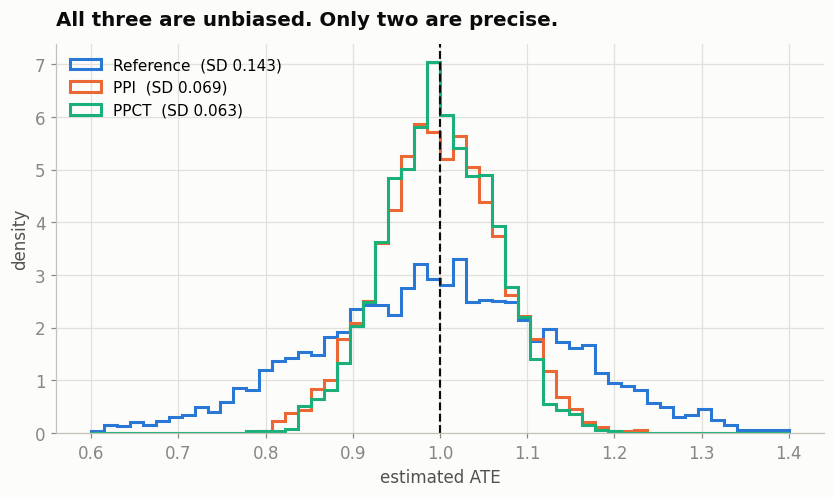

In [4]:
def sampling_dists(reps=4000, m=100, n=100, rho=0.9, delta=1.0):
    out, lams = {k: [] for k in ALL_ESTIMATORS}, []
    for _ in range(reps):
        Y, T, F = gen_trial(m, n, rho, delta)
        r = run_all(Y, T, F)
        for k, v in r.items():
            out[k].append(v.estimate)
        lams.append(r["PPCT"].lam)
    return pd.DataFrame(out), np.array(lams)

sd, lams = sampling_dists()
summary = pd.DataFrame({"mean": sd.mean(), "SD": sd.std(ddof=1)})
summary["SD vs Reference"] = summary.SD / summary.loc["Reference", "SD"]
summary["variance vs Reference"] = summary["SD vs Reference"] ** 2
display(summary.round(3))
print(f"\nlambda* averaged {lams.mean():.3f} (SD {lams.std():.3f});  "
      f"theory says 1 - rho^2 = {1 - 0.9**2:.3f} of the variance survives.")

fig, ax = plt.subplots(figsize=(9, 4.6))
bins = np.linspace(0.6, 1.4, 55)
for k in ["Reference", "PPI", "PPCT"]:
    ax.hist(sd[k], bins=bins, density=True, histtype="step", color=C[k], lw=2,
            label=f"{k}  (SD {sd[k].std():.3f})")
ax.axvline(1.0, color=INK, lw=1.4, ls="--")
ax.set(title="All three are unbiased. Only two are precise.",
       xlabel="estimated ATE", ylabel="density")
ax.legend(loc="upper left", fontsize=10)
plt.show()

With $\rho = 0.9$, theory says the variance should fall to $1-\rho^2 = 0.19$ of the
reference — a standard error cut by more than half, from a model that was never given a
single outcome from this trial.

Note also that PPCT beats plain PPI. PPI hard-codes $\lambda = 1$, which is optimal only
when the predictions are *perfect*. The next section shows what $\lambda=1$ costs when they
are not.

---
## 4. The paper's Table 2: unbalanced arms, and a skewed outcome

Here is where the estimators stop agreeing. We fix $m = 100$ treated and starve the control
arm down to $n = 2$, at three levels of prediction quality, for a Gaussian outcome and for a
right-skewed $\chi^2_5$ outcome.

This reproduces the structure of Table 2 in Poulet et al. (2025). Watch three things:

1. **ANCOVA explodes** at $n \le 5$. With two controls you cannot fit a slope.
2. **Plain PPI is worse than doing nothing** when $\rho = 0$ — it imports the model's noise
   with no compensating signal.
3. **PPCT drifts** in the skewed, tiny-$n$, high-$\rho$ corner, because $\hat\lambda^*$ is
   estimated from a handful of controls. **PPCT2 does not**, because its $\lambda$ estimator
   pools both arms.

In [5]:
def table2(reps=1500, ms=100):
    rows = []
    for dist in ["normal", "chisq"]:
        for rho in [0.0, 0.5, 0.95]:
            for n in [2, 5, 10, 50, 100]:
                est = {k: [] for k in ALL_ESTIMATORS}
                for _ in range(reps):
                    Y, T, F = gen_trial(ms, n, rho, 1.0, dist)
                    for k, r in run_all(Y, T, F).items():
                        est[k].append(r.estimate)
                row = {"dist": dist, "rho": rho, "n": n}
                for k, v in est.items():
                    row[k] = f"{np.mean(v):.2f} ± {np.std(v, ddof=1):.2f}"
                rows.append(row)
    return pd.DataFrame(rows)

t2 = table2()
print("mean ± SD of the estimated ATE over 1,500 simulated trials (true ATE = 1, m = 100)\n")
display(t2.style.hide(axis="index"))

mean ± SD of the estimated ATE over 1,500 simulated trials (true ATE = 1, m = 100)



dist,rho,n,Reference,PPI,PPCT,PPCT2,ANCOVA
normal,0.000000,2,1.05 ± 0.71,1.06 ± 1.01,1.05 ± 0.71,1.05 ± 0.72,2.30 ± 59.05
normal,0.000000,5,1.00 ± 0.46,1.00 ± 0.66,1.01 ± 0.51,1.00 ± 0.47,1.01 ± 0.57
normal,0.000000,10,1.00 ± 0.32,1.00 ± 0.46,1.01 ± 0.33,1.00 ± 0.32,1.01 ± 0.33
normal,0.000000,50,1.00 ± 0.17,1.01 ± 0.24,1.00 ± 0.17,1.00 ± 0.17,1.00 ± 0.17
normal,0.000000,100,1.00 ± 0.14,1.00 ± 0.20,1.00 ± 0.14,1.00 ± 0.14,1.00 ± 0.14
normal,0.500000,2,0.97 ± 0.72,1.00 ± 1.20,0.97 ± 0.72,0.97 ± 0.62,0.98 ± 36.56
normal,0.500000,5,1.01 ± 0.46,1.03 ± 0.82,1.00 ± 0.45,1.01 ± 0.40,1.01 ± 0.47
normal,0.500000,10,0.99 ± 0.34,0.98 ± 0.58,0.99 ± 0.31,0.99 ± 0.30,0.99 ± 0.31
normal,0.500000,50,1.00 ± 0.17,1.00 ± 0.30,1.00 ± 0.15,1.00 ± 0.15,1.00 ± 0.15
normal,0.500000,100,1.00 ± 0.14,1.00 ± 0.24,1.00 ± 0.12,1.00 ± 0.12,1.00 ± 0.12


---
### The same thing as a picture

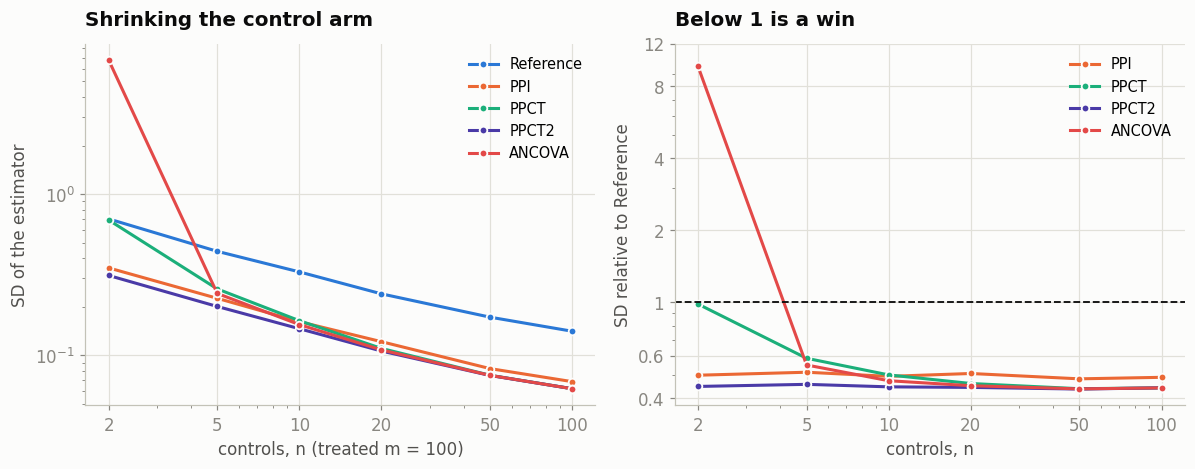

In [6]:
def unbalanced(reps=2000, m=100, rho=0.9, ns=(2, 5, 10, 20, 50, 100)):
    rows = []
    for n in ns:
        d = {k: [] for k in ALL_ESTIMATORS}
        for _ in range(reps):
            Y, T, F = gen_trial(m, n, rho, 1.0)
            for k, v in run_all(Y, T, F).items():
                d[k].append(v.estimate)
        for k, v in d.items():
            rows.append({"n": n, "estimator": k, "sd": np.std(v, ddof=1)})
    return pd.DataFrame(rows)

ub = unbalanced()
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
for k in ORDER:
    d = ub[ub.estimator == k]
    ax[0].plot(d.n, d.sd, "-o", ms=5, color=C[k], label=k, mec=SURF, mew=1.2)
ax[0].set(xscale="log", yscale="log", xlabel="controls, n (treated m = 100)",
          ylabel="SD of the estimator", title="Shrinking the control arm")
ref = ub[ub.estimator == "Reference"].set_index("n")["sd"]
for k in ["PPI", "PPCT", "PPCT2", "ANCOVA"]:
    d = ub[ub.estimator == k]
    ax[1].plot(d.n, d.sd.values / ref[d.n].values, "-o", ms=5, color=C[k],
               label=k, mec=SURF, mew=1.2)
ax[1].axhline(1, color=INK, lw=1.2, ls="--")
ax[1].set(xscale="log", yscale="log", xlabel="controls, n",
          ylabel="SD relative to Reference", title="Below 1 is a win")
ax[1].set_yticks([0.4, 0.6, 1, 2, 4, 8, 12]); ax[1].set_yticklabels("0.4 0.6 1 2 4 8 12".split())
for a in ax:
    a.set_xticks([2, 5, 10, 20, 50, 100]); a.set_xticklabels([2, 5, 10, 20, 50, 100])
    a.legend(fontsize=9.5)
plt.tight_layout(); plt.show()

---
## 5. What if the model is wrong?

This is the part that makes the method usable. The prognostic model here is wrong in two
independent ways:

1. **Structurally** — the truth is non-linear in $X$ (sines, squares, interactions) and the
   model is a plain linear regression;
2. **In calibration** — it is trained on a historical cohort measured on a different scale,
   so every prediction is off by $+15$ units.

We compare against a *naive* estimator that uses the model as a digital twin and never
rectifies it: $\frac1m\sum_{T=1} Y_i - \frac1N\sum_i f(X_i)$.

true ATE = 2.0



,mean,std
Reference,2.003,0.386
PPI,2.003,0.349
PPCT,2.002,0.348
PPCT2,2.002,0.348
ANCOVA,2.002,0.348
Naive (ML only),-12.990,0.328
lambda,0.945,0.158
rho,0.433,0.046


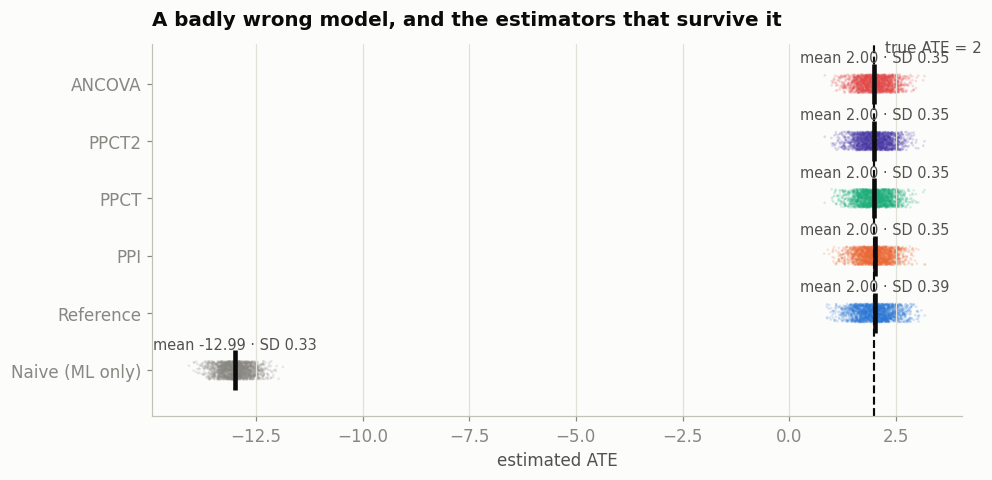

In [7]:
from sklearn.linear_model import LinearRegression

def world(N, rng, delta=2.0, p=5, noise=2.0):
    X = rng.normal(0, 1, (N, p))
    mu = 3*np.sin(1.5*X[:, 0]) + 1.2*X[:, 1]**2 - 1.5*X[:, 2]*X[:, 3] + X[:, 4]
    T = rng.binomial(1, 0.5, N)
    return X, mu + delta*T + rng.normal(0, noise, N), T, mu

def misspec_experiment(reps=2000, n_hist=600, N=400, delta=2.0, shift=15.0, seed=11):
    rng = np.random.default_rng(seed); rows = []
    for _ in range(reps):
        Xh, Yh, Th, _ = world(n_hist, rng, delta)
        lm = LinearRegression().fit(Xh[Th == 0], Yh[Th == 0] + shift)  # controls only, mis-calibrated
        X, Y, T, mu = world(N, rng, delta)
        f = lm.predict(X)
        r = run_all(Y, T, f)
        rows.append({**{k: v.estimate for k, v in r.items()},
                     "Naive (ML only)": Y[T == 1].mean() - f.mean(),
                     "lambda": r["PPCT"].lam, "rho": np.corrcoef(f, Y)[0, 1]})
    return pd.DataFrame(rows)

ms = misspec_experiment()
print("true ATE = 2.0\n")
display(ms.agg(["mean", "std"]).T.round(3))

names = ["Naive (ML only)"] + ORDER
fig, ax = plt.subplots(figsize=(9.5, 4.4))
for i, k in enumerate(names):
    v = ms[k].values
    ax.scatter(v, np.full_like(v, i) + np.random.uniform(-.16, .16, len(v)),
               s=3, alpha=.18, color=C[k], edgecolors="none")
    ax.plot([v.mean()], [i], "|", ms=26, mew=3, color=INK)
    ax.annotate(f"mean {v.mean():.2f} · SD {v.std(ddof=1):.2f}", (v.mean(), i),
                xytext=(0, 14), textcoords="offset points", ha="center",
                color=INK2, fontsize=9.5)
ax.axvline(2.0, color=INK, lw=1.4, ls="--")
ax.annotate("true ATE = 2", (2.0, len(names) - 0.45), xytext=(7, 0),
            textcoords="offset points", color=INK2, fontsize=10)
ax.set_yticks(range(len(names)), names)
ax.set(xlabel="estimated ATE", ylim=(-0.8, len(names) - 0.3),
       title="A badly wrong model, and the estimators that survive it")
ax.grid(axis="y", visible=False)
plt.show()

The naive estimator is off by exactly the calibration error. Every rectified estimator is
dead on the truth. The model's *bias* is absorbed by the rectifier; only the model's
*correlation with the outcome* changes the variance — and here that correlation is a
mediocre $\rho \approx 0.43$, which buys roughly a 10% variance reduction. A wrong model
costs you nothing and gains you little. That asymmetry is the whole safety argument.

---
## 6. Power, and the sample size you can hand back

Variance reduction converts directly into sample size (Proposition 8 of the paper):

$$N = \mathbb{V}\!\left(\widehat{\mathrm{ATE}}\right)\left(\frac{z_{1-\alpha/2} + z_{1-\beta}}{\Delta_H}\right)^2.$$

And for the specific question "how small can the control arm be, if the treated arm stays
at $m$?", the paper's design rule is

$$\frac{n_*}{m} = \sqrt{1 - \rho_c^2}.$$

At $\rho_c = 0.9$, you need 44 controls per 100 treated to match a balanced trial's power.
At $\rho_c = 1$ — a perfect prognostic model — you need none.

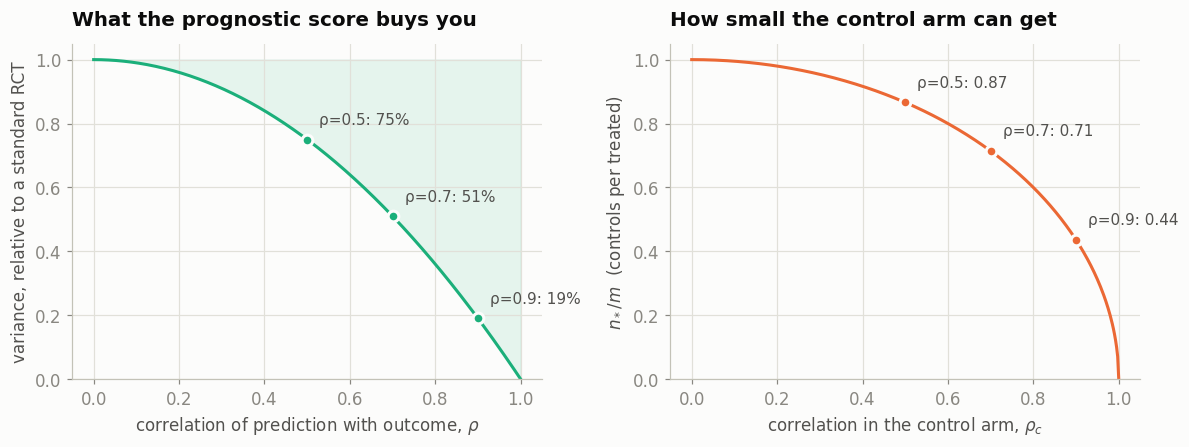

rho_c  0.0   0.1   0.2   0.3   0.4   0.5  0.6   0.7  0.8   0.9  1.0
n*/m   1.0  0.99  0.98  0.95  0.92  0.87  0.8  0.71  0.6  0.44  0.0


In [8]:
rho = np.linspace(0, 1, 400)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].plot(rho, 1 - rho**2, color=C["PPCT"])
ax[0].fill_between(rho, 1 - rho**2, 1, color=C["PPCT"], alpha=0.10)
ax[0].set(title="What the prognostic score buys you", ylim=(0, 1.05),
          xlabel=r"correlation of prediction with outcome, $\rho$",
          ylabel="variance, relative to a standard RCT")
ax[1].plot(rho, control_arm_ratio(rho), color=C["PPI"])
ax[1].set(title="How small the control arm can get", ylim=(0, 1.05),
          xlabel=r"correlation in the control arm, $\rho_c$",
          ylabel=r"$n_*/m$  (controls per treated)")
for r in (0.5, 0.7, 0.9):
    ax[0].plot([r], [1-r**2], "o", ms=7, color=C["PPCT"], mec=SURF, mew=2, zorder=3)
    ax[0].annotate(f"ρ={r}: {100*(1-r**2):.0f}%", (r, 1-r**2), xytext=(8, 10),
                   textcoords="offset points", color=INK2, fontsize=10)
    y = float(control_arm_ratio(r))
    ax[1].plot([r], [y], "o", ms=7, color=C["PPI"], mec=SURF, mew=2, zorder=3)
    ax[1].annotate(f"ρ={r}: {y:.2f}", (r, y), xytext=(8, 10),
                   textcoords="offset points", color=INK2, fontsize=10)
for a in ax: a.xaxis.set_major_locator(MultipleLocator(0.2))
plt.tight_layout(); plt.show()

print(pd.DataFrame({"rho_c": np.arange(0, 1.01, 0.1).round(1),
                    "n*/m": control_arm_ratio(np.arange(0, 1.01, 0.1)).round(2)})
      .set_index("rho_c").T.to_string())

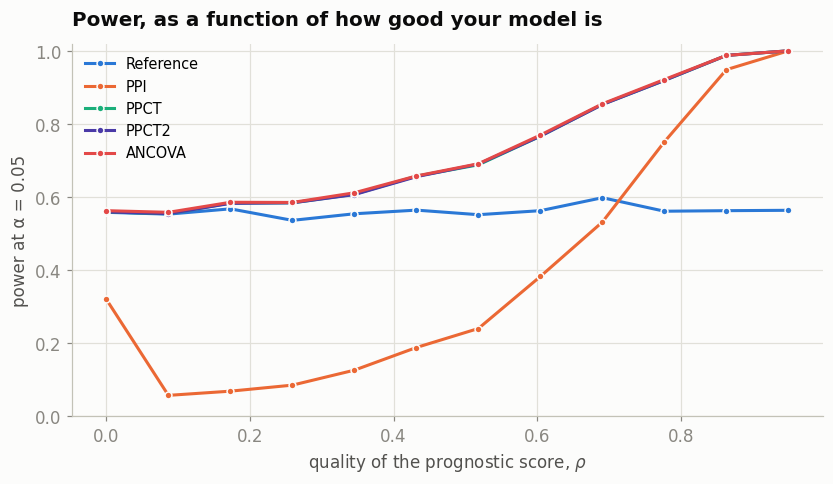


empirical type-I error at alpha = 0.05 (m = 100, n = 20, rho = 0.9):
{'Reference': 0.0583, 'PPI': 0.052, 'PPCT': 0.0663, 'PPCT2': 0.0505, 'ANCOVA': 0.068}


In [9]:
def power_curve(reps=2000, m=100, n=100, delta=0.3):
    rows = []
    for rho in np.linspace(0.0, 0.95, 12):
        hit = {k: 0 for k in ALL_ESTIMATORS}
        for _ in range(reps):
            Y, T, F = gen_trial(m, n, rho, delta)
            for k, v in run_all(Y, T, F).items():
                hit[k] += int(v.reject(0.05))
        for k, v in hit.items():
            rows.append({"rho": rho, "estimator": k, "power": v / reps})
    return pd.DataFrame(rows)

pw = power_curve()
fig, ax = plt.subplots(figsize=(8.8, 4.4))
for k in ORDER:
    d = pw[pw.estimator == k]
    ax.plot(d.rho, d.power, "-o", ms=4.5, color=C[k], label=k, mec=SURF, mew=1)
ax.set(xlabel=r"quality of the prognostic score, $\rho$", ylim=(0, 1.02),
       ylabel="power at α = 0.05", title="Power, as a function of how good your model is")
ax.legend(fontsize=9.5, loc="upper left")
plt.show()

# type-I error under the null, in a deliberately unbalanced design
hit = {k: 0 for k in ALL_ESTIMATORS}
REPS = 4000
for _ in range(REPS):
    Y, T, F = gen_trial(100, 20, 0.9, delta=0.0)
    for k, v in run_all(Y, T, F).items():
        hit[k] += int(v.reject(0.05))
print("\nempirical type-I error at alpha = 0.05 (m = 100, n = 20, rho = 0.9):")
print({k: round(v / REPS, 4) for k, v in hit.items()})

---
## 7. Real trial data: ACTG 175

ACTG 175 (Hammer et al., *NEJM* 1996) randomised 2,139 HIV-positive adults with baseline CD4 counts between 200 and 500 to
zidovudine monotherapy or to one of three alternative regimens. We take

* **outcome** — CD4 T-cell count at 20 ± 5 weeks (higher is better; fully observed);
* **treatment** — `treat = 1` for anything other than ZDV monotherapy;
* **baseline covariates** — 15 pre-randomisation variables (age, weight, Karnofsky score,
  prior therapy, CD4 and CD8 at baseline, …).

**The transfer-learning step.** We split the patients in two. One half becomes a *historical
cohort*: from it we keep only the ZDV-only patients and fit a gradient-boosting model of
CD4-at-20-weeks on baseline covariates. That is our stand-in for a disease progression model
calibrated on a previous trial's control arm or a natural-history registry. The other half is
the *target trial*, and the model never sees any of its outcomes.

The data ships inside the R package `BART`; we pull the `.rda` straight from CRAN's GitHub
mirror.

In [10]:
import pyreadr, urllib.request, os
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

URL = "https://raw.githubusercontent.com/cran/BART/master/data/ACTG175.rda"
if not os.path.exists("ACTG175.rda"):
    urllib.request.urlretrieve(URL, "ACTG175.rda")
actg = pyreadr.read_r("ACTG175.rda")["ACTG175"]
print(actg.shape)
display(actg.head(3))

BASE = ["age", "wtkg", "hemo", "homo", "drugs", "karnof", "oprior", "z30",
        "preanti", "race", "gender", "str2", "symptom", "cd40", "cd80"]

rng = np.random.default_rng(7)
is_hist = rng.random(len(actg)) < 0.50
hist, trial = actg[is_hist].copy(), actg[~is_hist].copy()

h = hist[hist.treat == 0]                      # historical CONTROLS only
model = GradientBoostingRegressor(n_estimators=300, max_depth=2, learning_rate=0.05,
                                  subsample=0.8, random_state=0).fit(h[BASE], h.cd420)
trial["f"] = model.predict(trial[BASE])

ctrl = trial[trial.treat == 0]
print(f"\nhistorical cohort: {len(hist)} patients, of whom {len(h)} ZDV-only -> model training set")
print(f"target trial:      {len(trial)} patients "
      f"({(trial.treat==1).sum()} treated, {(trial.treat==0).sum()} control)")
print(f"out-of-sample R² of f on the target trial's control arm: "
      f"{r2_score(ctrl.cd420, ctrl.f):.3f}")
print(f"rho_c = {np.corrcoef(ctrl.f, ctrl.cd420)[0,1]:.3f},  "
      f"rho_t = {np.corrcoef(trial[trial.treat==1].f, trial[trial.treat==1].cd420)[0,1]:.3f}")

(2139, 27)


,pidnum,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,zprior,...,offtrt,cd40,cd420,cd496,r,cd80,cd820,cens,days,arms
0,10056,48,89.8128,0,0,0,100,0,0,1,...,0,422,477,660,1,566,324,0,948,2
1,10059,61,49.4424,0,0,0,90,0,1,1,...,0,162,218,NaN,0,392,564,1,1002,3
2,10089,45,88.4520,0,1,1,90,0,1,1,...,1,326,274,122,1,2063,1893,0,961,3



historical cohort: 1078 patients, of whom 265 ZDV-only -> model training set
target trial:      1061 patients (794 treated, 267 control)
out-of-sample R² of f on the target trial's control arm: 0.378
rho_c = 0.621,  rho_t = 0.597


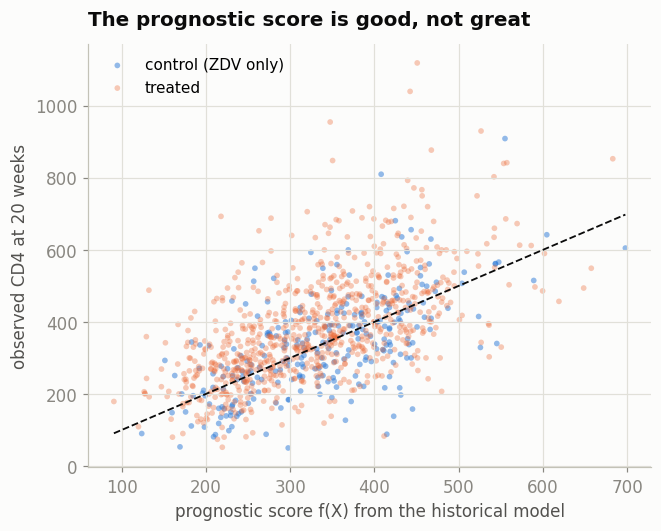

In [11]:
t = trial[trial.treat == 1]; c = trial[trial.treat == 0]
fig, ax = plt.subplots(figsize=(6.6, 5.0))
ax.scatter(c.f, c.cd420, s=14, alpha=.5, color=C["Reference"], edgecolors="none",
           label="control (ZDV only)")
ax.scatter(t.f, t.cd420, s=14, alpha=.35, color=C["PPI"], edgecolors="none", label="treated")
lim = [trial.f.min(), trial.f.max()]
ax.plot(lim, lim, color=INK, lw=1.2, ls="--")
ax.set(xlabel="prognostic score f(X) from the historical model",
       ylabel="observed CD4 at 20 weeks", title="The prognostic score is good, not great")
ax.legend(fontsize=10, loc="upper left")
plt.show()

,estimator,ate,se,ci_lo,ci_hi,p,lambda,se_ratio,var_ratio
0,Reference,45.5945,9.7955,26.3957,64.7933,0.0,0.0000,1.0000,1.0000
1,PPI,54.7150,7.7801,39.4663,69.9637,0.0,1.0000,0.7943,0.6308
2,PPCT,53.6027,7.7352,38.4420,68.7633,0.0,0.8780,0.7897,0.6236
3,PPCT2,53.8324,7.7371,38.6680,68.9968,0.0,0.9032,0.7899,0.6239
4,ANCOVA,53.7715,7.6635,38.7513,68.7916,0.0,NaN,0.7823,0.6121


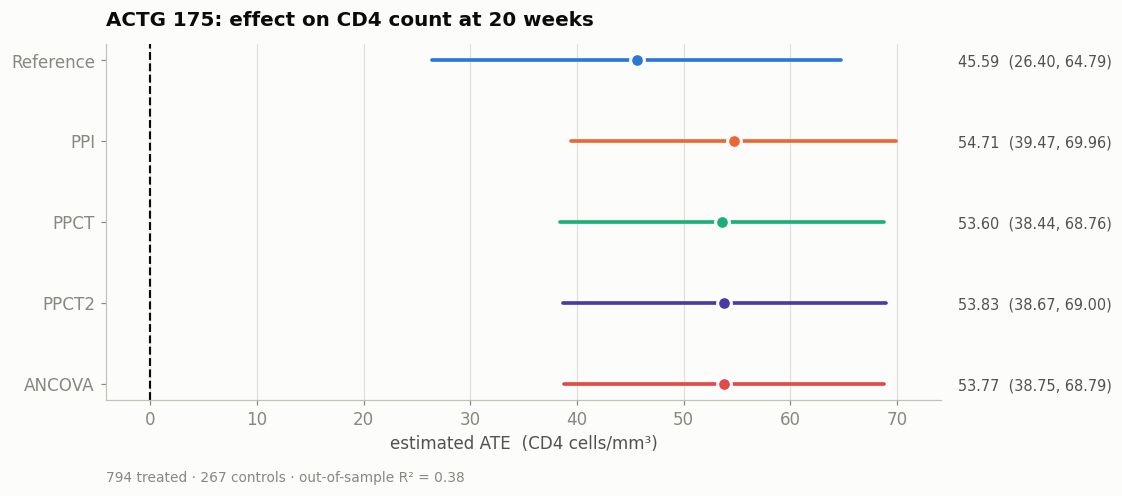


Total N for 80% power at the observed effect size, Reference = 100:
{'Reference': 100, 'PPI': 63, 'PPCT': 62, 'PPCT2': 62, 'ANCOVA': 61}

design rule n*/m = sqrt(1 - rho_c^2) = 0.784


In [12]:
def forest(res, title, note, unit=""):
    res = res.set_index("estimator").loc[ORDER].reset_index()
    ys = np.arange(len(res))[::-1]
    fig, ax = plt.subplots(figsize=(9.8, 4.2))
    for y, (_, r) in zip(ys, res.iterrows()):
        ax.plot([r.ci_lo, r.ci_hi], [y, y], color=C[r.estimator], lw=2.4,
                solid_capstyle="round")
        ax.plot([r.ate], [y], "o", ms=9, color=C[r.estimator], mec=SURF, mew=2, zorder=3)
        ax.annotate(f"{r.ate:.2f}  ({r.ci_lo:.2f}, {r.ci_hi:.2f})", (1.02, y),
                    xycoords=("axes fraction", "data"), xytext=(0, -4),
                    textcoords="offset points", color=INK2, fontsize=9.5)
    ax.axvline(0, color=INK, lw=1.4, ls="--")
    ax.set_yticks(ys, res.estimator)
    ax.set(title=title, xlabel=f"estimated ATE{unit}")
    ax.grid(axis="y", visible=False); ax.margins(x=0.06)
    ax.annotate(note, (0.0, -0.20), xycoords="axes fraction", color=MUTED,
                fontsize=9, va="top")
    plt.show()

def table(Y, T, F):
    res = run_all(Y, T, F)
    ref_se = res["Reference"].se
    rows = []
    for k, r in res.items():
        lo, hi = r.ci()
        rows.append({"estimator": k, "ate": r.estimate, "se": r.se, "ci_lo": lo,
                     "ci_hi": hi, "p": r.pvalue(), "lambda": r.lam,
                     "se_ratio": r.se / ref_se, "var_ratio": (r.se / ref_se) ** 2})
    return pd.DataFrame(rows)

res = table(trial.cd420.values, trial.treat.values, trial.f.values)
display(res.round(4))

forest(res, "ACTG 175: effect on CD4 count at 20 weeks",
       f"{(trial.treat==1).sum()} treated · {(trial.treat==0).sum()} controls · "
       f"out-of-sample R² = {r2_score(ctrl.cd420, ctrl.f):.2f}",
       unit="  (CD4 cells/mm³)")

# sample size for an equally powered future trial, indexed to Reference = 100
N = len(trial); delta = res.loc[res.estimator == "Reference", "ate"].iloc[0]
ss = {r.estimator: sample_size(r.se**2 * N, delta) for _, r in res.iterrows()}
print("\nTotal N for 80% power at the observed effect size, Reference = 100:")
print({k: round(100 * v / ss["Reference"]) for k, v in ss.items()})
print(f"\ndesign rule n*/m = sqrt(1 - rho_c^2) = "
      f"{float(control_arm_ratio(np.corrcoef(ctrl.f, ctrl.cd420)[0,1])):.3f}")

### Why did the point estimate move?

The reference estimator and PPCT disagree by about 8 CD4 units. That is not a bug, and it is
not a contradiction — it is the correction doing its job.

Randomisation balances covariates *in expectation*, not in any particular trial. In this
split, the treated arm happened to draw patients with a slightly worse prognosis: their mean
prognostic score is lower than the controls'. The difference in means silently charges the
treatment for that bad luck. PPCT subtracts $\lambda^*$ times the imbalance, and the two
numbers below should match exactly.

In [13]:
fm = trial.groupby("treat").f.mean()
lam = res.loc[res.estimator == "PPCT", "lambda"].iloc[0]
shift_expected = lam * (fm[1] - fm[0])
shift_observed = (res.loc[res.estimator == "PPCT", "ate"].iloc[0]
                  - res.loc[res.estimator == "Reference", "ate"].iloc[0])
print(f"mean f(X):  treated {fm[1]:.2f}   control {fm[0]:.2f}   "
      f"imbalance {fm[1]-fm[0]:+.2f}")
print(f"lambda* = {lam:.3f}")
print(f"-lambda* × imbalance = {-shift_expected:+.3f}")
print(f"PPCT − Reference     = {shift_observed:+.3f}")

mean f(X):  treated 330.62   control 339.74   imbalance -9.12
lambda* = 0.878
-lambda* × imbalance = +8.008
PPCT − Reference     = +8.008


### How much control arm do you actually need?

Now the practical question. We resample sub-trials out of the real data: a fixed 200 treated
patients, and a control arm shrunk from 200 down to 10, 600 times each. The spread of the
estimates across resamples is the sampling distribution of a design with those arm sizes.

estimator,ANCOVA,PPCT,PPCT2,PPI,Reference
n_control,,,,,
10,36.09,36.55,34.45,34.36,45.28
20,24.47,24.44,24.08,24.15,29.94
40,16.77,16.91,16.75,16.69,22.62
80,11.77,11.78,11.88,11.85,15.45
120,10.20,10.21,10.27,10.18,13.11
200,8.22,8.22,8.22,8.18,9.98


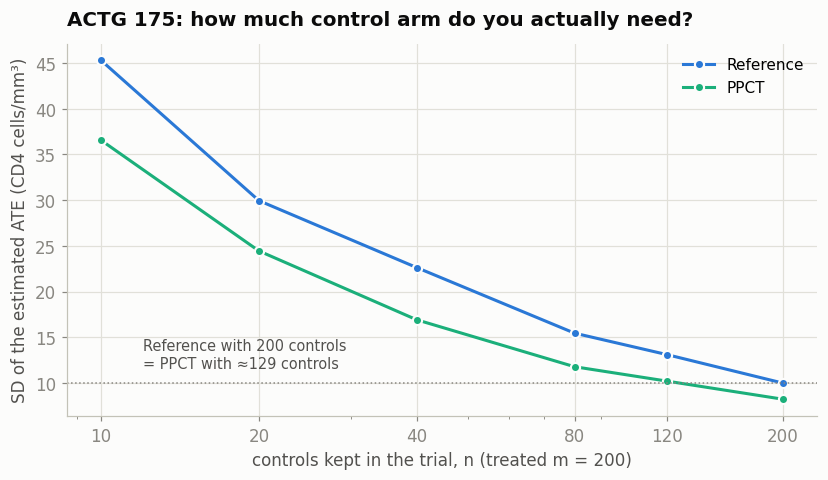

empirical SD vs the closed-form SE (a check on the variance formula):


estimator,ANCOVA,PPCT,PPCT2,PPI,Reference
n_control,,,,,
10,31.07,32.23,34.68,35.23,42.33
20,23.79,24.30,25.00,25.25,31.80
40,18.26,18.52,18.70,18.85,23.66
80,14.34,14.48,14.51,14.60,18.38
120,12.73,12.80,12.81,12.89,16.15
200,11.28,11.27,11.27,11.32,14.19


In [14]:
def shrink_control(data, ycol, tcol, fcol, m=200, ns=(10, 20, 40, 80, 120, 200),
                   reps=600, seed=1):
    rng = np.random.default_rng(seed)
    t = data[data[tcol] == 1].reset_index(drop=True)
    c = data[data[tcol] == 0].reset_index(drop=True)
    rows = []
    for n in ns:
        if n > len(c) or m > len(t):
            continue
        acc = {k: [] for k in ALL_ESTIMATORS}; ses = {k: [] for k in ALL_ESTIMATORS}
        for _ in range(reps):
            sub = pd.concat([t.iloc[rng.choice(len(t), m, replace=False)],
                             c.iloc[rng.choice(len(c), n, replace=False)]])
            for k, r in run_all(sub[ycol].values, sub[tcol].values, sub[fcol].values).items():
                acc[k].append(r.estimate); ses[k].append(r.se)
        for k in acc:
            rows.append({"n_control": n, "estimator": k, "mean": np.mean(acc[k]),
                         "sd_empirical": np.std(acc[k], ddof=1),
                         "se_analytic": np.mean(ses[k])})
    return pd.DataFrame(rows)

ub_actg = shrink_control(trial, "cd420", "treat", "f")
display(ub_actg.pivot(index="n_control", columns="estimator", values="sd_empirical").round(2))

fig, ax = plt.subplots(figsize=(8.8, 4.4))
for k in ["Reference", "PPCT"]:
    d = ub_actg[ub_actg.estimator == k]
    ax.plot(d.n_control, d.sd_empirical, "-o", ms=6, color=C[k], label=k, mec=SURF, mew=1.4)
ppc = ub_actg[ub_actg.estimator == "PPCT"]
ref = ub_actg[ub_actg.estimator == "Reference"]
target = float(ref[ref.n_control == 200].sd_empirical.iloc[0])
equiv = float(np.interp(-target, -ppc.sd_empirical, ppc.n_control))
ax.axhline(target, color=MUTED, lw=1, ls=":")
ax.annotate(f"Reference with 200 controls\n= PPCT with ≈{equiv:.0f} controls", (12, target),
            xytext=(0, 10), textcoords="offset points", color=INK2, fontsize=9.5)
ax.set(xscale="log", xlabel="controls kept in the trial, n (treated m = 200)",
       ylabel="SD of the estimated ATE (CD4 cells/mm³)",
       title="ACTG 175: how much control arm do you actually need?")
ax.set_xticks([10, 20, 40, 80, 120, 200]); ax.set_xticklabels([10, 20, 40, 80, 120, 200])
ax.legend(fontsize=10)
plt.show()

print("empirical SD vs the closed-form SE (a check on the variance formula):")
display(ub_actg.pivot(index="n_control", columns="estimator",
                      values="se_analytic").round(2))

The closed-form standard errors track the resampled ones closely. They run slightly *above*
the empirical spread at large $n$, which is expected: we are drawing without replacement from
a finite pool of real patients, so the resampled trials are less variable than genuinely
independent ones would be.

---
## 8. NHANES: the same machinery, without randomisation

The user-facing appeal of PPI is that it looks like a free lunch: plug in a model, get a
narrower interval. This section is the bill.

[NHANES](https://www.cdc.gov/nchs/nhanes/) is a repeated cross-sectional health survey. We
use it exactly the way the transfer-learning story suggests: train the prognostic model on
the **2009-10 wave**, then treat the **2011-12 wave** as the target study. Outcome: average
systolic blood pressure. "Treatment": whether the respondent reports being physically active.

Everything about the machinery is identical to the ACTG analysis. One thing is not:
**nobody randomised anyone.**

training wave 2009-10: 1961 adults (935 inactive -> model)
target wave 2011-12:   1725 adults (949 active, 776 inactive)
out-of-sample R² on the inactive group: 0.344


,estimator,ate,se,ci_lo,ci_hi,p,lambda,se_ratio,var_ratio
0,Reference,-2.8367,0.7873,-4.3799,-1.2936,0.0003,0.0000,1.0000,1.0000
1,PPI,0.7344,0.6454,-0.5305,1.9993,0.2551,1.0000,0.8197,0.6719
2,PPCT,0.6554,0.6453,-0.6093,1.9201,0.3098,0.9779,0.8196,0.6717
3,PPCT2,0.5541,0.6454,-0.7109,1.8191,0.3906,0.9495,0.8197,0.6720
4,ANCOVA,0.6771,0.6553,-0.6073,1.9616,0.3015,NaN,0.8323,0.6928


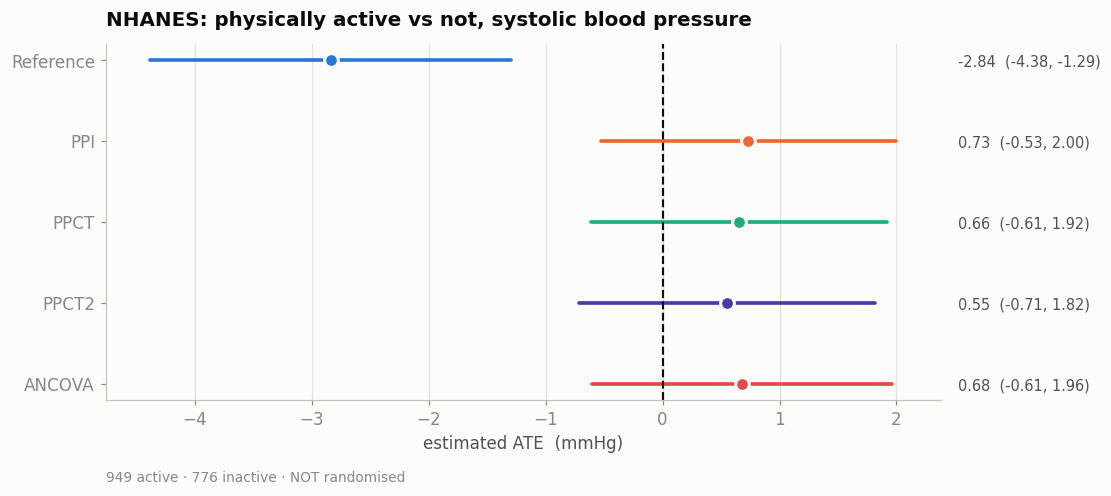

In [15]:
NH_URL = "https://raw.githubusercontent.com/cran/NHANES/master/data/NHANES.rda"
if not os.path.exists("NHANES.rda"):
    urllib.request.urlretrieve(NH_URL, "NHANES.rda")
nh = pyreadr.read_r("NHANES.rda")["NHANES"]

NH_NUM = ["Age", "BMI", "Weight", "Height", "Pulse", "TotChol", "Poverty",
          "DirectChol", "BPDiaAve"]
NH_CAT = ["Gender", "Race1", "Diabetes", "Smoke100"]

df = nh[(nh.Age >= 20) & (nh.Age <= 79)]
df = df[NH_NUM + NH_CAT + ["BPSysAve", "PhysActive", "SurveyYr"]].dropna().drop_duplicates()
X = pd.get_dummies(df[NH_NUM + NH_CAT], drop_first=True).astype(float)
df = df.assign(**{c: X[c] for c in X.columns}); feats = list(X.columns)

train  = df[df.SurveyYr == "2009_10"]
target = df[df.SurveyYr == "2011_12"].copy()

tr = train[train.PhysActive == "No"]                     # "control-like" respondents
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
nmodel = make_pipeline(StandardScaler(),
                       GradientBoostingRegressor(n_estimators=400, max_depth=2,
                                                 learning_rate=0.05, subsample=0.8,
                                                 random_state=0)).fit(tr[feats], tr.BPSysAve)
target["f"] = nmodel.predict(target[feats])
target["T"] = (target.PhysActive == "Yes").astype(int)

nctrl = target[target["T"] == 0]
print(f"training wave 2009-10: {len(train)} adults ({len(tr)} inactive -> model)")
print(f"target wave 2011-12:   {len(target)} adults "
      f"({(target['T']==1).sum()} active, {(target['T']==0).sum()} inactive)")
print(f"out-of-sample R² on the inactive group: {r2_score(nctrl.BPSysAve, nctrl.f):.3f}")

nres = table(target.BPSysAve.values, target["T"].values, target.f.values)
display(nres.round(4))
forest(nres, "NHANES: physically active vs not, systolic blood pressure",
       f"{(target['T']==1).sum()} active · {(target['T']==0).sum()} inactive · NOT randomised",
       unit="  (mmHg)")

Look at what happened. The difference in means says active respondents run about 2.8 mmHg
lower, comfortably "significant". Every prediction-powered estimator says the effect is
roughly zero.

In the ACTG analysis the same correction moved the estimate by less than one standard error,
because randomisation kept the prognostic imbalance small and random. Here it is neither
small nor random — and the decomposition is the same arithmetic as before.

In [16]:
nfm = target.groupby("T").f.mean()
nlam = nres.loc[nres.estimator == "PPCT", "lambda"].iloc[0]
act, inact = target[target["T"] == 1], target[target["T"] == 0]
print(f"mean age:  active {act.Age.mean():.1f}   inactive {inact.Age.mean():.1f}")
print(f"mean BMI:  active {act.BMI.mean():.1f}   inactive {inact.BMI.mean():.1f}")
print(f"\nmean f(X): active {nfm[1]:.2f}   inactive {nfm[0]:.2f}   "
      f"imbalance {nfm[1]-nfm[0]:+.2f}")
print(f"lambda* = {nlam:.3f}")
print(f"-lambda* × imbalance = {-nlam*(nfm[1]-nfm[0]):+.3f}")
print(f"PPCT − Reference     = "
      f"{nres.loc[nres.estimator=='PPCT','ate'].iloc[0] - nres.loc[nres.estimator=='Reference','ate'].iloc[0]:+.3f}")

ub_nh = shrink_control(target, "BPSysAve", "T", "f", m=300,
                       ns=(25, 50, 100, 200, 300, 600))
display(ub_nh.pivot(index="n_control", columns="estimator", values="sd_empirical").round(2))

mean age:  active 42.6   inactive 48.6
mean BMI:  active 28.1   inactive 30.0

mean f(X): active 117.82   inactive 121.39   imbalance -3.57
lambda* = 0.978
-lambda* × imbalance = +3.492
PPCT − Reference     = +3.492


estimator,ANCOVA,PPCT,PPCT2,PPI,Reference
n_control,,,,,
25,2.88,3.01,2.92,2.90,3.62
50,1.83,1.89,1.86,1.84,2.27
100,1.42,1.43,1.47,1.44,1.75
200,1.05,1.05,1.07,1.04,1.31
300,0.91,0.90,0.90,0.88,1.07
600,0.74,0.74,0.70,0.68,0.82


The physically active respondents are six years younger and nearly two BMI units lighter.
$f(X)$ knows this, because age and BMI are what it was trained on, so the correction removes
most of the crude association.

Two lessons, and they point in opposite directions:

* **The variance reduction is real without randomisation.** The resampling table above shows
  the same ~20% standard-error cut in NHANES as in ACTG 175. That part of PPI is just
  arithmetic about correlation.
* **The estimand is not.** $\widehat{\mathrm{ATE}}^{\,\mathrm{PPI}\lambda}$ equals the ATE
  *because* $\mathbb{E}[f(X) \mid T=1] = \mathbb{E}[f(X)\mid T=0]$ under randomisation. Break
  that and the same formula quietly estimates something else — a
  prognostic-score-adjusted contrast, which is closer to the causal quantity you want here,
  but is still not identified, because the adjustment can only remove confounding that the
  model's covariates capture.

PPI fixes variance. It does not fix confounding, and it will not tell you which of the two
you had.

---
## 9. What to take away

1. **The rectifier is the whole trick.** Predictions enter twice with opposite signs, so
   whatever the model gets systematically wrong cancels. Unbiasedness does not depend on the
   model being right.
2. **Use $\lambda^*$, not $\lambda = 1$.** Plain PPI is *worse* than doing nothing when the
   predictions are poor. PPCT is never worse than the reference estimator, by construction:
   $\mathbb{V}^{\mathrm{PPCT}} = \mathbb{V}^{\mathrm{ref}} - (\lambda^*)^2\sigma_f^2(1/n+1/m)$.
3. **The exchange rate is $\rho^2$.** A prognostic score correlated $\rho$ with the outcome
   cuts variance to $1-\rho^2$, and lets the control arm shrink to $\sqrt{1-\rho_c^2}$ of its
   balanced size. Predicting a *change* over the trial window is much harder than predicting
   a level — check your $\rho$ before promising anyone a smaller trial.
4. **PPCT and ANCOVA are asymptotically equivalent**, and differ where it matters in
   practice: very small control arms, where ANCOVA's slope estimate falls apart and the
   PPI form still has a closed-form variance.
5. **Randomisation is load-bearing.** Everything above is a variance argument conditional on
   $X \perp T$. Section 8 is what the same code does when that fails.

### References

- Poulet P-E, Tran M, Tezenas du Montcel S, Dubois B, Durrleman S, Jedynak B (2025).
  Prediction-powered inference for clinical trials: application to linear covariate
  adjustment. *BMC Med Res Methodol* 25:204. https://doi.org/10.1186/s12874-025-02647-6
- Angelopoulos AN, Bates S, Fannjiang C, Jordan MI, Zrnic T (2023). Prediction-powered
  inference. *Science* 382:669-674. https://doi.org/10.1126/science.adi6000
- Angelopoulos AN, Duchi JC, Zrnic T (2023). PPI++: Efficient prediction-powered inference.
  https://arxiv.org/abs/2311.01453
- Schuler A, Walsh D, Hall D, Walsh J, Fisher C (2022). Increasing the efficiency of
  randomized trial estimates via linear adjustment for a prognostic score.
  *Int J Biostat* 18(2):329-356. https://doi.org/10.1515/ijb-2021-0072
- Hammer SM, et al. (1996). A trial comparing nucleoside monotherapy with combination therapy
  in HIV-infected adults with CD4 cell counts from 200 to 500 per cubic millimeter.
  *NEJM* 335:1081-1090.
- EMA (2015). Guideline on adjustment for baseline covariates in clinical trials.